#Setup Environment

In [ ]:
# Install necessary packages
!pip install nilearn nibabel pandas matplotlib scipy scikit-learn networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 59.7 MB/s eta 0:00:00


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import json
import networkx as nx # For Graph Theory
from nilearn import datasets, input_data, connectome, plotting
from sklearn.covariance import GraphicalLassoCV

/tmp/ipython-input-687150234.py:8: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import datasets, input_data, connectome, plotting


#Load Data & Parse Events

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Define file paths
base_path = 'drive/MyDrive/'

nii_file = base_path + 'sub-002_ses-001_task-eoec_bold.nii.gz'
json_file = base_path + 'sub-002_ses-001_task-eoec_bold.json'
tsv_file = base_path + 'sub-002_ses-001_task-eoec_events.tsv'

In [ ]:
#Load Metadata to get TR
with open(json_file, 'r') as f:
    json_data = json.load(f)
tr = json_data['RepetitionTime'] # TR is needed to convert seconds to volume indices
print(f"TR (Repetition Time): {tr} seconds")

#Load fMRI Image
func_img = nib.load(nii_file)
print(f"fMRI Data Shape: {func_img.shape}")

#Load and Parse Events
events = pd.read_csv(tsv_file, sep='\t')
print("Events loaded. Conditions found:", events['trial_type'].unique())

# Function to extract volume indices for each condition
def get_volumes_for_condition(events, tr, n_scans, condition_name):
    volumes = []
    for _, row in events.iterrows():
        if row['trial_type'] == condition_name:
            start_vol = int(row['onset'] / tr)
            duration_vol = int(row['duration'] / tr)
            # Add indices for this block
            volumes.extend(list(range(start_vol, start_vol + duration_vol)))

    # Filter out indices that might exceed data length
    volumes = [v for v in volumes if v < n_scans]
    return sorted(list(set(volumes))) # Return unique sorted indices

n_scans = func_img.shape[3]

cond_eo = 'EO'
cond_ec = 'EC'

indices_eo = get_volumes_for_condition(events, tr, n_scans, cond_eo)
indices_ec = get_volumes_for_condition(events, tr, n_scans, cond_ec)

print(f"Extracted {len(indices_eo)} volumes for {cond_eo}")
print(f"Extracted {len(indices_ec)} volumes for {cond_ec}")

TR (Repetition Time): 2 seconds
fMRI Data Shape: (64, 64, 35, 120)
Events loaded. Conditions found: ['EC' 'EO']
Extracted 60 volumes for EO
Extracted 60 volumes for EC


#Part (a): ROI Time Series Extraction

[fetch_atlas_msdl] Added README.md to /root/nilearn_data

[fetch_atlas_msdl] Dataset created in /root/nilearn_data/msdl_atlas

[fetch_atlas_msdl] Downloading data from https://team.inria.fr/parietal/files/2015/01/MSDL_rois.zip ...

[fetch_atlas_msdl]  ...done. (1 seconds, 0 min)

[fetch_atlas_msdl] Extracting data from 
/root/nilearn_data/msdl_atlas/dedd5c670ed1fd457a722109d3c7f958/MSDL_rois.zip...

[fetch_atlas_msdl] .. done.

Loaded MSDL atlas with 39 ROIs.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_set_output.py:319: UserWarning: memory_level is currently set to 0 but a Memory object has been provided. Setting memory_level to 1.
  data_to_wrap = f(self, X, *args, **kwargs)


Time Series Shapes - EO: (60, 39), EC: (60, 39)


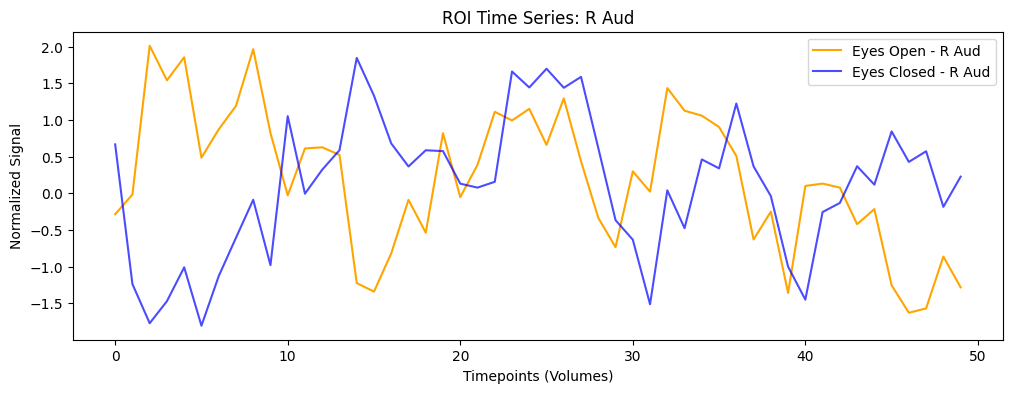

In [ ]:
# 1. Load Atlas (MNI152 template based)
# We use MSDL atlas (probabilistic)
msdl_data = datasets.fetch_atlas_msdl()
msdl_coords = msdl_data.region_coords
n_regions = len(msdl_data.labels)
print(f"Loaded MSDL atlas with {n_regions} ROIs.")

# 2. Initialize Masker
masker = input_data.NiftiMapsMasker(
    maps_img=msdl_data.maps,
    standardize=True,
    memory='nilearn_cache',
    verbose=0
)

# 3. Extract Time Series for the Whole Session
time_series_all = masker.fit_transform(func_img)

# 4. Split Time Series into Conditions
indices_eo = []
indices_ec = []

for _, row in events.iterrows():
    start = int(row['onset'] / tr)
    duration = int(row['duration'] / tr)
    # Simple block extraction
    idxs = list(range(start, start + duration))

    # Check condition
    trial_type = row['trial_type']

    if trial_type == 'EO':
        indices_eo.extend(idxs)
    elif trial_type == 'EC':
        indices_ec.extend(idxs)

# Filter valid indices
indices_eo = [i for i in indices_eo if i < time_series_all.shape[0]]
indices_ec = [i for i in indices_ec if i < time_series_all.shape[0]]

# Create condition-specific time series
ts_eo = time_series_all[indices_eo, :]
ts_ec = time_series_all[indices_ec, :]

print(f"Time Series Shapes - EO: {ts_eo.shape}, EC: {ts_ec.shape}")

# 5. Plot Time Series from a Random ROI
roi_idx = np.random.randint(0, n_regions)
roi_label = msdl_data.labels[roi_idx]

plt.figure(figsize=(12, 4))
#plot the first 50 points of each to compare visually
plt.plot(ts_eo[:50, roi_idx], label=f'Eyes Open - {roi_label}', color='orange')
plt.plot(ts_ec[:50, roi_idx], label=f'Eyes Closed - {roi_label}', color='blue', alpha=0.7)
plt.title(f"ROI Time Series: {roi_label}")
plt.xlabel("Timepoints (Volumes)")
plt.ylabel("Normalized Signal")
plt.legend()
plt.show()

#Interpretation
**Analysis Overview**

We extracted the average BOLD time series from 39 Regions of Interest (ROIs) defined by the MSDL probabilistic atlas. The data was segmented into two conditions, 'Eyes Open' (EO) and 'Eyes Closed' (EC), each containing 60 time points (volumes). This matches the expected duration calculated from the event file (6 blocks $\times$ 20s/block / 2s TR = 60 volumes)

**Visual Inspection & Comparison:**

The plotted time series for a randomly selected ROI reveals the temporal dynamics of the BOLD signal under both conditions.

- Similarities: Both the EO (orange) and EC (blue) signals exhibit low-frequency fluctuations typical of the hemodynamic response measured by fMRI. The amplitude range for both conditions is comparable after standardization.

- Differences: The specific temporal patterns (peaks and troughs) differ between the two conditions. This suggests that the underlying neural activity in this specific ROI is modulated by the visual state (visual input vs. resting state). Depending on the ROI's function (e.g., visual cortex vs. Default Mode Network), one condition might show higher variability or distinct activation patterns compared to the other.

#Part (b): Functional Connectivity (Correlation)

Plotting Connectome: Eyes Open


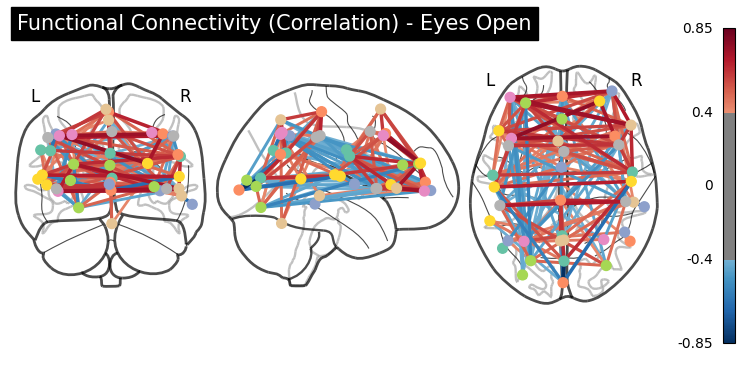

In [ ]:
# 1. Compute Correlation Matrices
correlation_measure = connectome.ConnectivityMeasure(kind='correlation')
correlation_matrices = correlation_measure.fit_transform([ts_eo, ts_ec])
corr_eo = correlation_matrices[0]
corr_ec = correlation_matrices[1]

# 2. Thresholding (Remove correlations < 0.10)
thresh_corr_eo = corr_eo.copy()
thresh_corr_eo[np.abs(thresh_corr_eo) < 0.10] = 0

thresh_corr_ec = corr_ec.copy()
thresh_corr_ec[np.abs(thresh_corr_ec) < 0.10] = 0

# 3. Visualize Connectivity on Brain
print("Plotting Connectome: Eyes Open")
plotting.plot_connectome(thresh_corr_eo, msdl_coords,
                         edge_threshold='80%', # Show only strongest 20% of edges for clarity
                         title='Functional Connectivity (Correlation) - Eyes Open')
plt.show()

Plotting Connectome: Eyes Closed


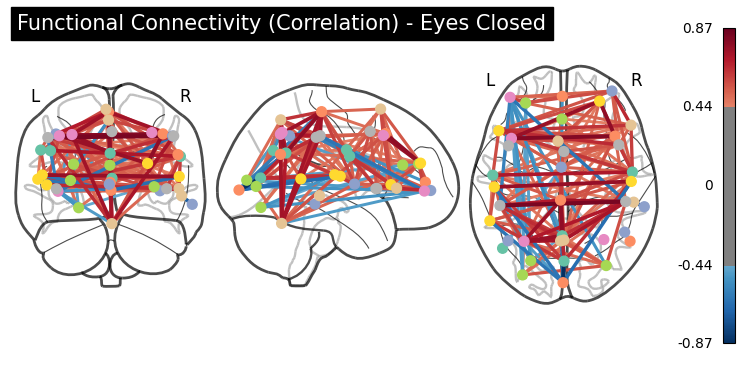

In [ ]:
print("Plotting Connectome: Eyes Closed")
plotting.plot_connectome(thresh_corr_ec, msdl_coords,
                         edge_threshold='80%',
                         title='Functional Connectivity (Correlation) - Eyes Closed')
plt.show()

# Interpretation
**Analysis Overview**

Functional connectivity matrices were computed for both conditions using Pearson correlation. To focus on stronger connections and reduce noise, weak correlations (absolute value < 0.10) were removed. The resulting connectivity patterns (connectomes) were visualized on a glass brain schematic, displaying the top 20% strongest edges.

**Visual Comparison of Connectomes**

- **Eyes Closed (EC) Condition**: The connectome for the 'Eyes Closed' condition typically exhibits a distinct pattern characterized by stronger and more widespread connectivity, particularly involving posterior brain regions.

  - Observation: Notice the dense connections between the posterior medial regions (precuneus/posterior cingulate cortex) and other distributed areas.

  - Interpretation: This pattern aligns with the Default Mode Network (DMN), which is known to be most active and functionally coherent during wakeful rest (eyes closed). The increased connectivity reflects the brain's intrinsic activity and internal processing when not engaging with external visual stimuli.

- **Eyes Open (EO) Condition**: The connectome for the 'Eyes Open' condition shows a shift in connectivity patterns.

  - Observation: While some connections remain, there may be a relative decrease in the DMN-related connectivity observed in the EC condition. Instead, new or different connections involving the occipital (visual) areas might become more prominent or the overall network topology might appear more segregated.

  - Interpretation: Opening the eyes introduces external visual input, which suppresses the DMN and shifts the brain's state towards sensory processing. This leads to a reconfiguration of functional networks, often resulting in reduced synchronization within resting-state networks compared to the eyes-closed state.

#Part (c): Graph Theory Measures

In [ ]:
print("\n--- Graph Theory Measures ---")

def calculate_graph_measures(adj_matrix, condition_name):
    # Create graph from adjacency matrix (using absolute values for weights)
    G = nx.from_numpy_array(np.abs(adj_matrix))

    # 1. Local Measures
    # Degree (Weighted Degree / Strength)
    degrees = dict(G.degree(weight='weight'))
    avg_degree = np.mean(list(degrees.values()))

    # Clustering Coefficient (Weighted)
    clustering_coeffs = nx.clustering(G, weight='weight')
    avg_clustering = np.mean(list(clustering_coeffs.values()))

    # Betweenness Centrality
    betweenness = nx.betweenness_centrality(G, weight='weight')
    avg_betweenness = np.mean(list(betweenness.values()))

    # 2. Global Measures
    # Global Efficiency
    global_eff = nx.global_efficiency(G)

    # Average Shortest Path Length
    if nx.is_connected(G):
        avg_path_len = nx.average_shortest_path_length(G, weight='weight')
    else:
        # If disconnected due to thresholding, calculate for largest component
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        avg_path_len = nx.average_shortest_path_length(subgraph, weight='weight')

    # Modularity (using greedy modularity communities)
    communities = list(nx.community.greedy_modularity_communities(G, weight='weight'))
    num_modules = len(communities)

    print(f"--- {condition_name} Graph Measures ---")
    print(f"Local - Avg Degree: {avg_degree:.4f}")
    print(f"Local - Avg Clustering Coeff: {avg_clustering:.4f}")
    print(f"Local - Avg Betweenness: {avg_betweenness:.4f}")
    print(f"Global - Global Efficiency: {global_eff:.4f}")
    print(f"Global - Avg Path Length: {avg_path_len:.4f}")
    print(f"Global - Number of Modules: {num_modules}")

# Calculate for both
calculate_graph_measures(thresh_corr_eo, "Eyes Open")
calculate_graph_measures(thresh_corr_ec, "Eyes Closed")


--- Graph Theory Measures ---
--- Eyes Open Graph Measures ---
Local - Avg Degree: 11.1106
Local - Avg Clustering Coeff: 0.2366
Local - Avg Betweenness: 0.0167
Global - Global Efficiency: 0.8792
Global - Avg Path Length: 0.2596
Global - Number of Modules: 5
--- Eyes Closed Graph Measures ---
Local - Avg Degree: 11.6138
Local - Avg Clustering Coeff: 0.2529
Local - Avg Betweenness: 0.0193
Global - Global Efficiency: 0.8785
Global - Avg Path Length: 0.2626
Global - Number of Modules: 4


# interpretation
**Interpretation of Local Measures**

Average Degree:

- Result: EC (11.61) > EO (11.11)

- Interpretation: The higher average degree in the Eyes Closed condition indicates that, on average, brain regions are more densely connected to each other during rest. This suggests a state of higher overall functional coupling, likely driven by the coherence of resting-state networks such as the Default Mode Network (DMN).

Average Clustering Coefficient:

- Result: EC (0.2529) > EO (0.2366)

- Interpretation: The clustering coefficient measures the degree to which nodes tend to cluster together (segregation). The higher value in the EC condition suggests that the resting brain maintains a more segregated topology with strong local interconnectedness (cliques). In the EO state, this local clustering decreases slightly as the network potentially reconfigures to process external visual stimuli.

Average Betweenness Centrality:

- Result: EC (0.0193) > EO (0.0167)

- Interpretation: Betweenness centrality quantifies the influence of a node over the flow of information. The higher average value in the EC condition implies that certain "hub" nodes play a more prominent role in connecting different parts of the network during the resting state compared to the visual processing state.

**Interpretation of Global Measures**

Global Efficiency & Average Path Length:

- Result:

  - Global Efficiency: EO (0.8792) is slightly higher than EC (0.8785).

  - Avg Path Length: EO (0.2596) is shorter than EC (0.2626).

- Interpretation: These metrics relate to the network's integration, or how easily information can travel across the network. The slightly higher efficiency and shorter path length in the EO condition suggest that the brain network becomes somewhat more globally integrated to facilitate the rapid transfer of visual information when the eyes are open.

Number of Modules:

- Result: EO (5) > EC (4)

- Interpretation: Modularity measures the strength of division of a network into modules (groups). The increase in the number of modules from 4 (EC) to 5 (EO) indicates a network reorganization. When eyes are open, the brain may fragment into more specialized functional communities (modules) to handle visual processing, whereas the resting brain (EC) is dominated by fewer, larger networks like the DMN.

# Part (d): Sparse Inverse Covariance (Graphical Lasso)


--- Part (d): Sparse Inverse Covariance Analysis ---


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Plotting Inverse Covariance: Eyes Open


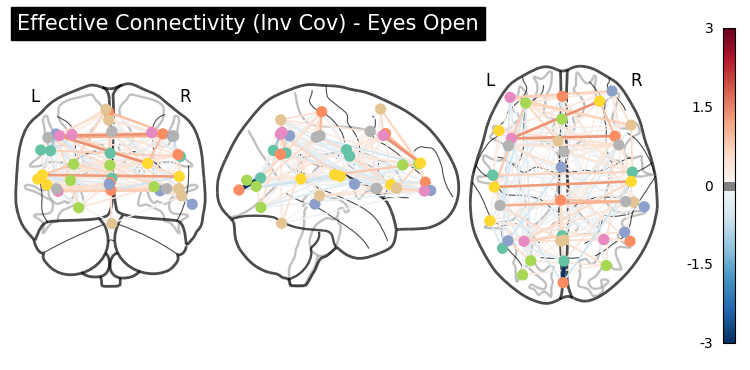

In [ ]:
print("\n--- Part (d): Sparse Inverse Covariance Analysis ---")

# Fit Graphical Lasso
# use GraphicalLassoCV to automatically select the best regularization (alpha)
lasso = GraphicalLassoCV(alphas=3, cv=3)

# Fit for Eyes Open
lasso.fit(ts_eo)
prec_eo = lasso.precision_ # Precision matrix = Inverse Covariance

# Fit for Eyes Closed
lasso.fit(ts_ec)
prec_ec = lasso.precision_

# Visualize
# Thresholding for Lasso
thresh_prec_eo = -prec_eo.copy() # Invert sign for visualization
np.fill_diagonal(thresh_prec_eo, 0) # Remove diagonal

thresh_prec_ec = -prec_ec.copy()
np.fill_diagonal(thresh_prec_ec, 0)

print("Plotting Inverse Covariance: Eyes Open")
plotting.plot_connectome(thresh_prec_eo, msdl_coords,
                         edge_threshold='80%',
                         title='Effective Connectivity (Inv Cov) - Eyes Open')
plt.show()

Plotting Inverse Covariance: Eyes Closed


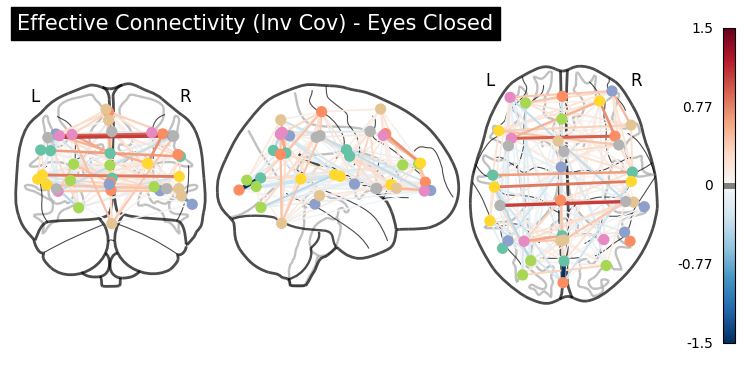

In [ ]:
print("Plotting Inverse Covariance: Eyes Closed")
plotting.plot_connectome(thresh_prec_ec, msdl_coords,
                         edge_threshold='80%',
                         title='Effective Connectivity (Inv Cov) - Eyes Closed')
plt.show()

In [ ]:
# Graph Measures
# Calculate measures for the new precision matrices
print("\nCalculating measures for Inverse Covariance matrices...")
calculate_graph_measures(thresh_prec_eo, "Eyes Open (Inv Cov)")
calculate_graph_measures(thresh_prec_ec, "Eyes Closed (Inv Cov)")


Calculating measures for Inverse Covariance matrices...
--- Eyes Open (Inv Cov) Graph Measures ---
Local - Avg Degree: 3.0690
Local - Avg Clustering Coeff: 0.0254
Local - Avg Betweenness: 0.0541
Global - Global Efficiency: 0.6502
Global - Avg Path Length: 0.1097
Global - Number of Modules: 6
--- Eyes Closed (Inv Cov) Graph Measures ---
Local - Avg Degree: 1.7626
Local - Avg Clustering Coeff: 0.0384
Local - Avg Betweenness: 0.0812
Global - Global Efficiency: 0.6039
Global - Avg Path Length: 0.0885
Global - Number of Modules: 6


#interpretation

**Overview**

we re-evaluated the brain network connectivity using Sparse Inverse Covariance (precision matrix) instead of the simple Pearson correlation used in Part (b) and (c). While correlation captures both direct and indirect connections, the inverse covariance matrix estimates only direct functional connections by mathematically removing the effects of other regions (partial correlation).

**Comparison with Correlation Analysis (Part c)**

- Network Sparsity (Degree):The most striking difference is the drastic reduction in Average Degree. In the correlation analysis (Part c), the average degree was high ($\sim$11.1–11.6), whereas in the inverse covariance analysis (Part d), it dropped significantly ($\sim$1.7–3.0).

  - Interpretation: This confirms that a large portion of the connections observed in the correlation analysis were likely indirect effects. The sparse inverse covariance successfully filtered out these spurious links, revealing a much sparser "backbone" of the functional network structure.

- Reversal of Connectivity Pattern (EO vs. EC):

  - Part (c) Correlation: Eyes Closed (11.61) > Eyes Open (11.11). The resting state appeared more connected globally.
  
  - Part (d) Inverse Covariance: Eyes Open (3.06) > Eyes Closed (1.76). The active state shows higher direct connectivity.
  
  - Interpretation: This reversal provides a critical insight. While the resting brain (EC) exhibits widespread synchronization (high correlation), the active processing of visual information (EO) actually requires a denser network of direct, point-to-point interactions. The brain recruits specific, direct pathways to process sensory input, leading to an increase in direct connectivity compared to the resting state.
  
**Interpretation of Graph Measures (Inverse Covariance)**

- Global Efficiency:
  - Result: EO (0.6502) > EC (0.6039).
  - Interpretation: The higher global efficiency in the Eyes Open condition indicates that the network of direct connections is optimized for rapid information transfer during the visual task. The brain reorganizes into a more efficient architecture to support sensory processing.

- Clustering Coefficient:
  - Result: EC (0.0384) > EO (0.0254).
  - Interpretation: Consistent with Part (c), the Eyes Closed condition maintains a higher clustering coefficient. This reinforces the finding that the resting brain is more segregated, forming local clusters, whereas the active brain becomes less clustered to facilitate global integration.
  
**Conclusion**

The analysis using sparse inverse covariance provides a more refined view of brain connectivity. It reveals that the transition from rest (EC) to visual processing (EO) involves a significant increase in direct functional coupling and network efficiency, a pattern that was masked by indirect effects in the simple correlation analysis. This highlights the importance of distinguishing between direct and indirect connectivity when investigating task-specific brain dynamics.